Loading imports

In [1]:
import json
import networkx as nx
from networkx.readwrite import json_graph
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from pathlib import Path
import math

Loading the saved graph

In [2]:
with open("rfa_graph.json", "r", encoding="utf-8") as f:
    graph_data = json.load(f)

G = json_graph.node_link_graph(graph_data, edges="edges")

print(type(G))
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

<class 'networkx.classes.multidigraph.MultiDiGraph'>
Nodes: 11381
Edges: 198275


Inspecting some edges to ensure graph is set up as intended

In [3]:
for i, (u, v, k, data) in enumerate(G.edges(keys=True, data=True)):
    print(f"{u} -> {v} (key={k})")
    print(data)
    print("-" * 40)
    if i == 4:
        break

Steel1943 -> BDD (key=0)
{'vote': 1, 'text': "'''Support''' as co-nom.", 'result': 1, 'year': 2013, 'date': '23:13, 19 April 2013'}
----------------------------------------
Steel1943 -> RockMagnetist (key=0)
{'vote': 0, 'text': '<del>\'\'\'Neutral\'\'\'</del>. \'\'\'Moral Support\'\'\'. I\'ve only run across RockMagnetist once in my travels in checking/editing articles on this Wikipedia, and RockMagnetist seems like a good candidate for this based on the description above. However, since I have to base my votes on the actual experience I have had with the user as an editor, I cannot sway my vote either way. Either way, I am leaning more towards a support, but since I vote based on interaction, I have neither any positive nor negative thoughts going through my head, so I vote "Neutral".', 'result': 1, 'year': 2013, 'date': '22:04, 9 March 2013'}
----------------------------------------
Steel1943 -> Shirt58 (key=0)
{'vote': 0, 'text': '\'\'\'Neutral\'\'\'. As I vote based on actual inter

Users who recieved the most votes

In [4]:
target_vote_counts = {}

for node in G.nodes():
    target_vote_counts[node] = G.in_degree(node)

top_targets_df = (
    pd.DataFrame(
        target_vote_counts.items(),
        columns=["target", "total_votes_received"]
    )
    .sort_values("total_votes_received", ascending=False)
    .reset_index(drop=True)
)

print(top_targets_df.head(20))

                            target  total_votes_received
0                        Everyking                   987
1                   TenPoundHammer                   778
2                        MZMcBride                   663
3                             Cobi                   639
4                           Elonka                   628
5                        Ironholds                   577
6                              Kww                   563
7                           Werdna                   540
8                        Enigmaman                   486
9                The Transhumanist                   476
10                       Robchurch                   445
11  Can't sleep, clown will eat me                   437
12                        Siva1979                   437
13                     HJ Mitchell                   420
14                         Majorly                   381
15                        Carnildo                   371
16                            G

Building reduced graph for visualization that only keeps top-voted targets and the users connected to them, collapses repeated edges into weighted edges

In [5]:
top_n = 10
min_targets_per_voter = 2

top_targets = set(top_targets_df.head(top_n)["target"])

# aggregate votes only for edges going into top targets
edge_stats = defaultdict(lambda: {"weight": 0, "vote_sum": 0})
voter_to_targets = defaultdict(set)

for u, v, k, data in G.edges(keys=True, data=True):
    if v in top_targets:
        edge_stats[(u, v)]["weight"] += 1
        edge_stats[(u, v)]["vote_sum"] += data["vote"]
        voter_to_targets[u].add(v)

# keep only voters who voted on multiple top targets
core_voters = {
    voter for voter, targets in voter_to_targets.items()
    if len(targets) >= min_targets_per_voter
}

H = nx.DiGraph()

H.add_nodes_from(top_targets)

for (u, v), stats in edge_stats.items():
    if u in core_voters:
        H.add_edge(
            u,
            v,
            weight=stats["weight"],
            mean_vote=stats["vote_sum"] / stats["weight"]
        )

print("Core graph:", H.number_of_nodes(), "nodes,", H.number_of_edges(), "edges")

Core graph: 1025 nodes, 3577 edges


Adding node attributes

In [10]:
for node in H.nodes():
    indeg = H.in_degree(node)
    outdeg = H.out_degree(node)
    score = 2 * indeg + outdeg

    # compress large differences into a small visual range
    H.nodes[node]["size"] = 2 + 2.5 * math.log1p(score)

    H.nodes[node]["title"] = (
        f"{node}<br>"
        f"In-degree: {indeg}<br>"
        f"Out-degree: {outdeg}"
    )
    H.nodes[node]["color"] = "red" if node in top_targets else "lightblue"

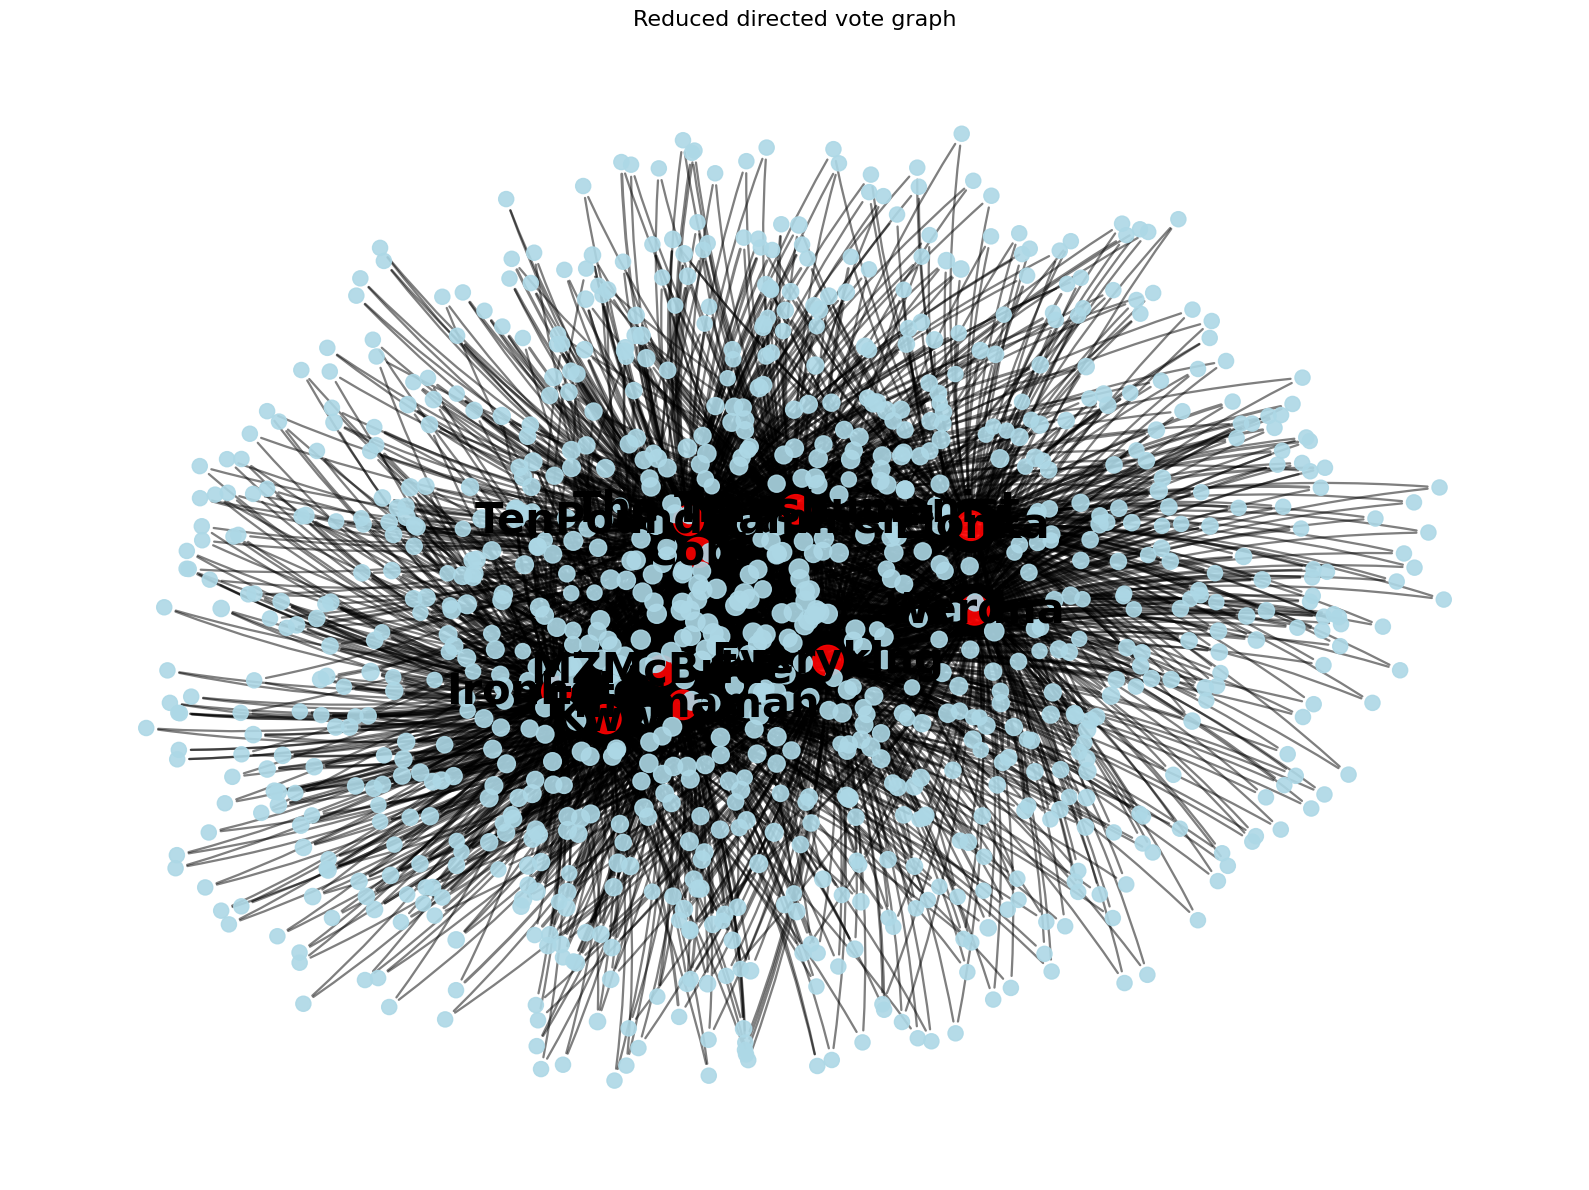

In [13]:
# Matplotlib + NetworkX visualization of H

plt.figure(figsize=(16, 12))

# layout
pos = nx.spring_layout(H, seed=42, k=2.5, iterations=100)

# node styling from your stored attributes
node_sizes = [H.nodes[n].get("size", 5) * 25 for n in H.nodes()]
node_colors = [H.nodes[n].get("color", "lightblue") for n in H.nodes()]

# edge widths based on aggregated vote count
edge_widths = [
    0.8 + 1.2 * math.log1p(H[u][v].get("weight", 1))
    for u, v in H.edges()
]

# draw nodes
nx.draw_networkx_nodes(
    H,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    alpha=0.9
)

# draw directed edges
nx.draw_networkx_edges(
    H,
    pos,
    width=edge_widths,
    arrows=True,
    arrowsize=18,
    arrowstyle='-|>',
    alpha=0.5,
    connectionstyle="arc3,rad=0.08"
)

# label only the top targets to avoid clutter
labels = {node: str(node) for node in top_targets if node in H.nodes()}

nx.draw_networkx_labels(
    H,
    pos,
    labels=labels,
    font_size=30,
    font_weight="bold"
)

plt.title("Reduced directed vote graph", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# make sure H exists and is not too large
print(H.number_of_nodes(), H.number_of_edges())

# create deterministic positions now so sigma does not need a layout plugin
H_sigma = H.copy()

pos = nx.spring_layout(H_sigma, seed=42, k=0.5)

nodes = []
for node in H_sigma.nodes():
    x, y = pos[node]
    nodes.append({
        "key": str(node),
        "label": str(node),
        "x": float(x),
        "y": float(y),
        "size": float(H_sigma.nodes[node].get("size", 5)),
        "color": H_sigma.nodes[node].get("color", "#66b3ff"),
    })

edges = []
for i, (u, v, data) in enumerate(H_sigma.edges(data=True)):
    edges.append({
        "key": f"e{i}",
        "source": str(u),
        "target": str(v),
        "size": 0.5 + 0.8 * math.log1p(float(data.get("weight", 1))),
        "color": "#999999",
    })

sigma_data = {
    "nodes": nodes,
    "edges": edges,
}

out_dir = Path("sigma_output")
out_dir.mkdir(exist_ok=True)

with open(out_dir / "graph.json", "w", encoding="utf-8") as f:
    json.dump(sigma_data, f, ensure_ascii=False)

print(f"Saved: {(out_dir / 'graph.json').resolve()}")

In [ ]:
from pathlib import Path

html = """<!doctype html>
<html lang="en">
<head>
  <meta charset="UTF-8" />
  <meta name="viewport" content="width=device-width, initial-scale=1.0" />
  <title>Sigma RfA Graph</title>
  <style>
    html, body, #container {
      margin: 0;
      padding: 0;
      width: 100%;
      height: 100vh;
      overflow: hidden;
      font-family: Arial, sans-serif;
    }
    #info {
      position: absolute;
      top: 10px;
      left: 10px;
      background: rgba(255,255,255,0.9);
      padding: 8px 10px;
      border-radius: 8px;
      z-index: 10;
      font-size: 14px;
    }
  </style>
</head>
<body>
  <div id="info">Sigma graph viewer</div>
  <div id="container"></div>

  <script type="module">
    import Graph from "https://cdn.jsdelivr.net/npm/graphology@0.26.0/+esm";
    import Sigma from "https://cdn.jsdelivr.net/npm/sigma@3.0.2/+esm";

    const response = await fetch("./graph.json");
    const data = await response.json();

    const graph = new Graph();

    for (const node of data.nodes) {
      graph.addNode(node.key, {
        label: node.label,
        x: node.x,
        y: node.y,
        size: node.size,
        color: node.color
      });
    }

    for (const edge of data.edges) {
      graph.addEdge(edge.source, edge.target, {
        size: edge.size,
        color: edge.color
      });
    }

    new Sigma(graph, document.getElementById("container"));
  </script>
</body>
</html>
"""

out_dir = Path("sigma_output")
with open(out_dir / "viewer.html", "w", encoding="utf-8") as f:
    f.write(html)

print(f"Saved: {(out_dir / 'viewer.html').resolve()}")